In [23]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Union, List, Optional
from psim_kernels import pairwise_kernel_tlj, pairwise_kernel_tmorse
from tqdm import tqdm
from time import time
import math

In [63]:
class DeformableParticleSystem:
    particle_id : torch.Tensor
    pos : torch.Tensor
    force : torch.Tensor
    volume : torch.Tensor
    shape : torch.Tensor
    cell_id : torch.Tensor
    cell_offsets : torch.Tensor

    def __init__(self, num_cells_per_dim : Union[int, Tuple[int, int, int]], cell_size : Union[float, Tuple[float, float, float]], device='cuda'):
        if isinstance(num_cells_per_dim, Tuple):
            self.num_cells_per_dim = num_cells_per_dim
            self.num_cells = self.num_cells_per_dim[0] * self.num_cells_per_dim[1] * self.num_cells_per_dim[2]
        elif isinstance(num_cells_per_dim, int):
            self.num_cells_per_dim = (num_cells_per_dim, num_cells_per_dim, num_cells_per_dim)
            self.num_cells = num_cells_per_dim ** 3
        else:
            raise ValueError("num_cells_per_dim must be either an integer or a tuple of three integers")
        self.num_cells_per_dim_tensor = torch.tensor(self.num_cells_per_dim, dtype=torch.long, device=device)
        if isinstance(cell_size, Tuple):
            self.cell_size = cell_size
        elif isinstance(cell_size, float):
            self.cell_size = (cell_size, cell_size, cell_size)
        else:
            raise ValueError("cell_size must be either a float or a tuple of three floats")
        self.cell_size_vec = torch.tensor(self.cell_size, dtype=torch.float32, device=device)
        self.box_size = (self.num_cells_per_dim[0] * self.cell_size[0], 
                            self.num_cells_per_dim[1] * self.cell_size[1], 
                            self.num_cells_per_dim[2] * self.cell_size[2])
        self.box_size_vec = torch.tensor(self.box_size, dtype=torch.float32, device=device)
        self.cell_offsets = torch.empty(self.num_cells + 1, dtype=torch.long, device=device)
        self.device = device

    def random_pos_init(self, num_particles):
        self.particle_id = torch.arange(num_particles, dtype=torch.long, device=self.device)
        self.pos = torch.empty((num_particles, 3), dtype=torch.float32, device=self.device)
        self.force = torch.empty((num_particles, 3), dtype=torch.float32, device=self.device)
        self.volume = torch.empty((num_particles,), dtype=torch.float32, device=self.device)
        self.shape = torch.empty((num_particles, 3, 3), dtype=torch.float32, device=self.device)
        self.cell_id = torch.empty((num_particles,), dtype=torch.long, device=self.device)
        self.pos[:,0].uniform_(0, self.box_size[0])
        self.pos[:,1].uniform_(0, self.box_size[1])
        self.pos[:,2].uniform_(0, self.box_size[2])
        self.force.zero_()
        self.volume.fill_(1.0)
        self.shape.zero_()

    def lattice_pos_init(self, number_density, jitter=0.0):
        num_particles = int(number_density * self.box_size[0] * self.box_size[1] * self.box_size[2])
    
        # number of grid points per side
        n = math.ceil(num_particles ** (1/3))
        linear_spacing = (self.box_size[0] * self.box_size[1] * self.box_size[2] / num_particles) ** (1/3)
    
        xs = (torch.arange(n, device=self.device, dtype=torch.float32) + 0.5) * linear_spacing
        ys = (torch.arange(n, device=self.device, dtype=torch.float32) + 0.5) * linear_spacing
        zs = (torch.arange(n, device=self.device, dtype=torch.float32) + 0.5) * linear_spacing
    
        X, Y, Z = torch.meshgrid(xs, ys, zs, indexing="ij")
        pos = torch.stack([X, Y, Z], dim=-1).reshape(-1, 3).contiguous()
        pos = pos[:num_particles]  # trim excess grid points
    
        if jitter > 0.0:
            pos = pos + jitter * (2 * torch.rand_like(pos) - 1)
        
        pos = pos % self.box_size_vec
        self.pos = pos
        num_particles = pos.shape[0]
        self.particle_id = torch.arange(num_particles, dtype=torch.long, device=self.device)
        self.force       = torch.empty((num_particles, 3),    dtype=torch.float32, device=self.device)
        self.volume      = torch.empty((num_particles,),      dtype=torch.float32, device=self.device)
        self.shape       = torch.empty((num_particles, 3, 3), dtype=torch.float32, device=self.device)
        self.cell_id     = torch.empty((num_particles,),      dtype=torch.long,    device=self.device)
        
    def update_cell_list(self):
        cell_coords = torch.floor(self.pos / self.cell_size_vec).long() % self.num_cells_per_dim_tensor
        nx, ny, nz = self.num_cells_per_dim
        cell_id = cell_coords[:, 0] + (cell_coords[:, 1] + cell_coords[:, 2] * ny)*nx
        cell_id_sorted, perm = torch.sort(cell_id) 
        self.cell_id = cell_id_sorted
        self.particle_id = self.particle_id[perm].contiguous()
        self.pos = self.pos[perm].contiguous()
        self.force = self.force[perm].contiguous()
        self.volume = self.volume[perm].contiguous()
        self.shape = self.shape[perm].contiguous()
        counts = torch.bincount(self.cell_id, minlength=self.num_cells)
        self.cell_offsets[0] = 0
        self.cell_offsets[1:] = torch.cumsum(counts, dim=0)

    def integrate(self, dt, noise_std=0.0):
        self.pos += self.force * dt
        if noise_std > 0.0:
            self.pos += torch.randn_like(self.pos) * (noise_std*np.sqrt(dt))
        self.pos = self.pos % self.box_size_vec
        self.force.zero_()

In [72]:
psys = DeformableParticleSystem(num_cells_per_dim=20, cell_size=1.0)
psys.lattice_pos_init(0.9,jitter=0.1)
num_time_steps = 100000
print("Number of particles:", psys.pos.shape[0])

Number of particles: 7200


In [73]:
t0 = time()
for step in range(num_time_steps):
    #if step % 10 == 0:
    #    psys.update_cell_list()
    psys.update_cell_list()
    pairwise_kernel_tmorse(pos = psys.pos,
                        force = psys.force,
                        cell_ids = psys.cell_id,
                        cell_offsets = psys.cell_offsets,
                        num_cells_per_dim = psys.num_cells_per_dim,
                        box_size=psys.box_size,
                        cutoff=1.0,
                        intensity=5.0,
                        location=0.5,
                        inverse_scale=0.1)
    psys.integrate(dt=1e-5, noise_std=0.0)
t1 = time()
print(f"Average time per step: {(t1-t0)/num_time_steps:.6f} seconds")

Average time per step: 0.000715 seconds


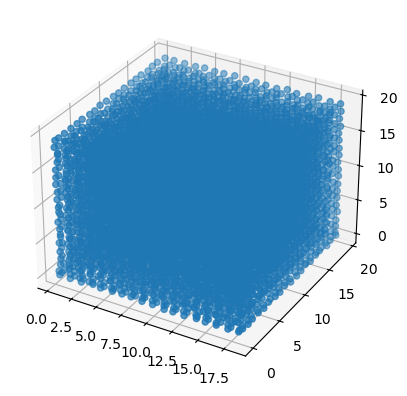

In [74]:
%matplotlib inline
pos_cpu = psys.pos.cpu().numpy()
force_cpu = psys.force.cpu().numpy()
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos_cpu[:,0], pos_cpu[:,1], pos_cpu[:,2])
plt.show()